In [54]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
import os
import sys

import cv2

import numpy as np 

import torch
import torch.nn as nn
import torch.nn.functional as F

from box import Box
import yaml

import matplotlib.pyplot as plt

from scipy.spatial.transform import Rotation as R
import random 

import time 

import tqdm

root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.models.dpso_inference import DPSO
from src.models.logger import DataLogger

from src.data_loader.evaluation_data_generator import DataGenerator
from src.models.patchifier import Patchifier
from src.data_loader.utils import img_polar2cart

from src.data_loader.metrics import pose_err


In [56]:
model_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/model.yaml'
sonar_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/sonar.yaml'

data_root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/SonarOdometryDataset/supervised/val/seq_14'
data_output_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/training/test_output2'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(model_config_pth, "r") as f:
            model_config = Box(yaml.safe_load(f))
with open(sonar_config_pth, "r") as f:
            sonar_config = Box(yaml.safe_load(f))

init_frames = model_config.TIME_WINDOW
r_min = sonar_config.range.min
r_max = sonar_config.range.max
theta_max = sonar_config.fov.horizontal


from src.data_loader.transforms import SonarDatasetTranforms
data_generator = DataGenerator(data_root_dir, device, transforms = SonarDatasetTranforms)
data_lenght = data_generator.get_len()
print(f'Data generator initialized.')
print(f'Data series lenght: {data_lenght}')

patchifier = Patchifier(model_config)

Data generator initialized.
Data series lenght: 1000


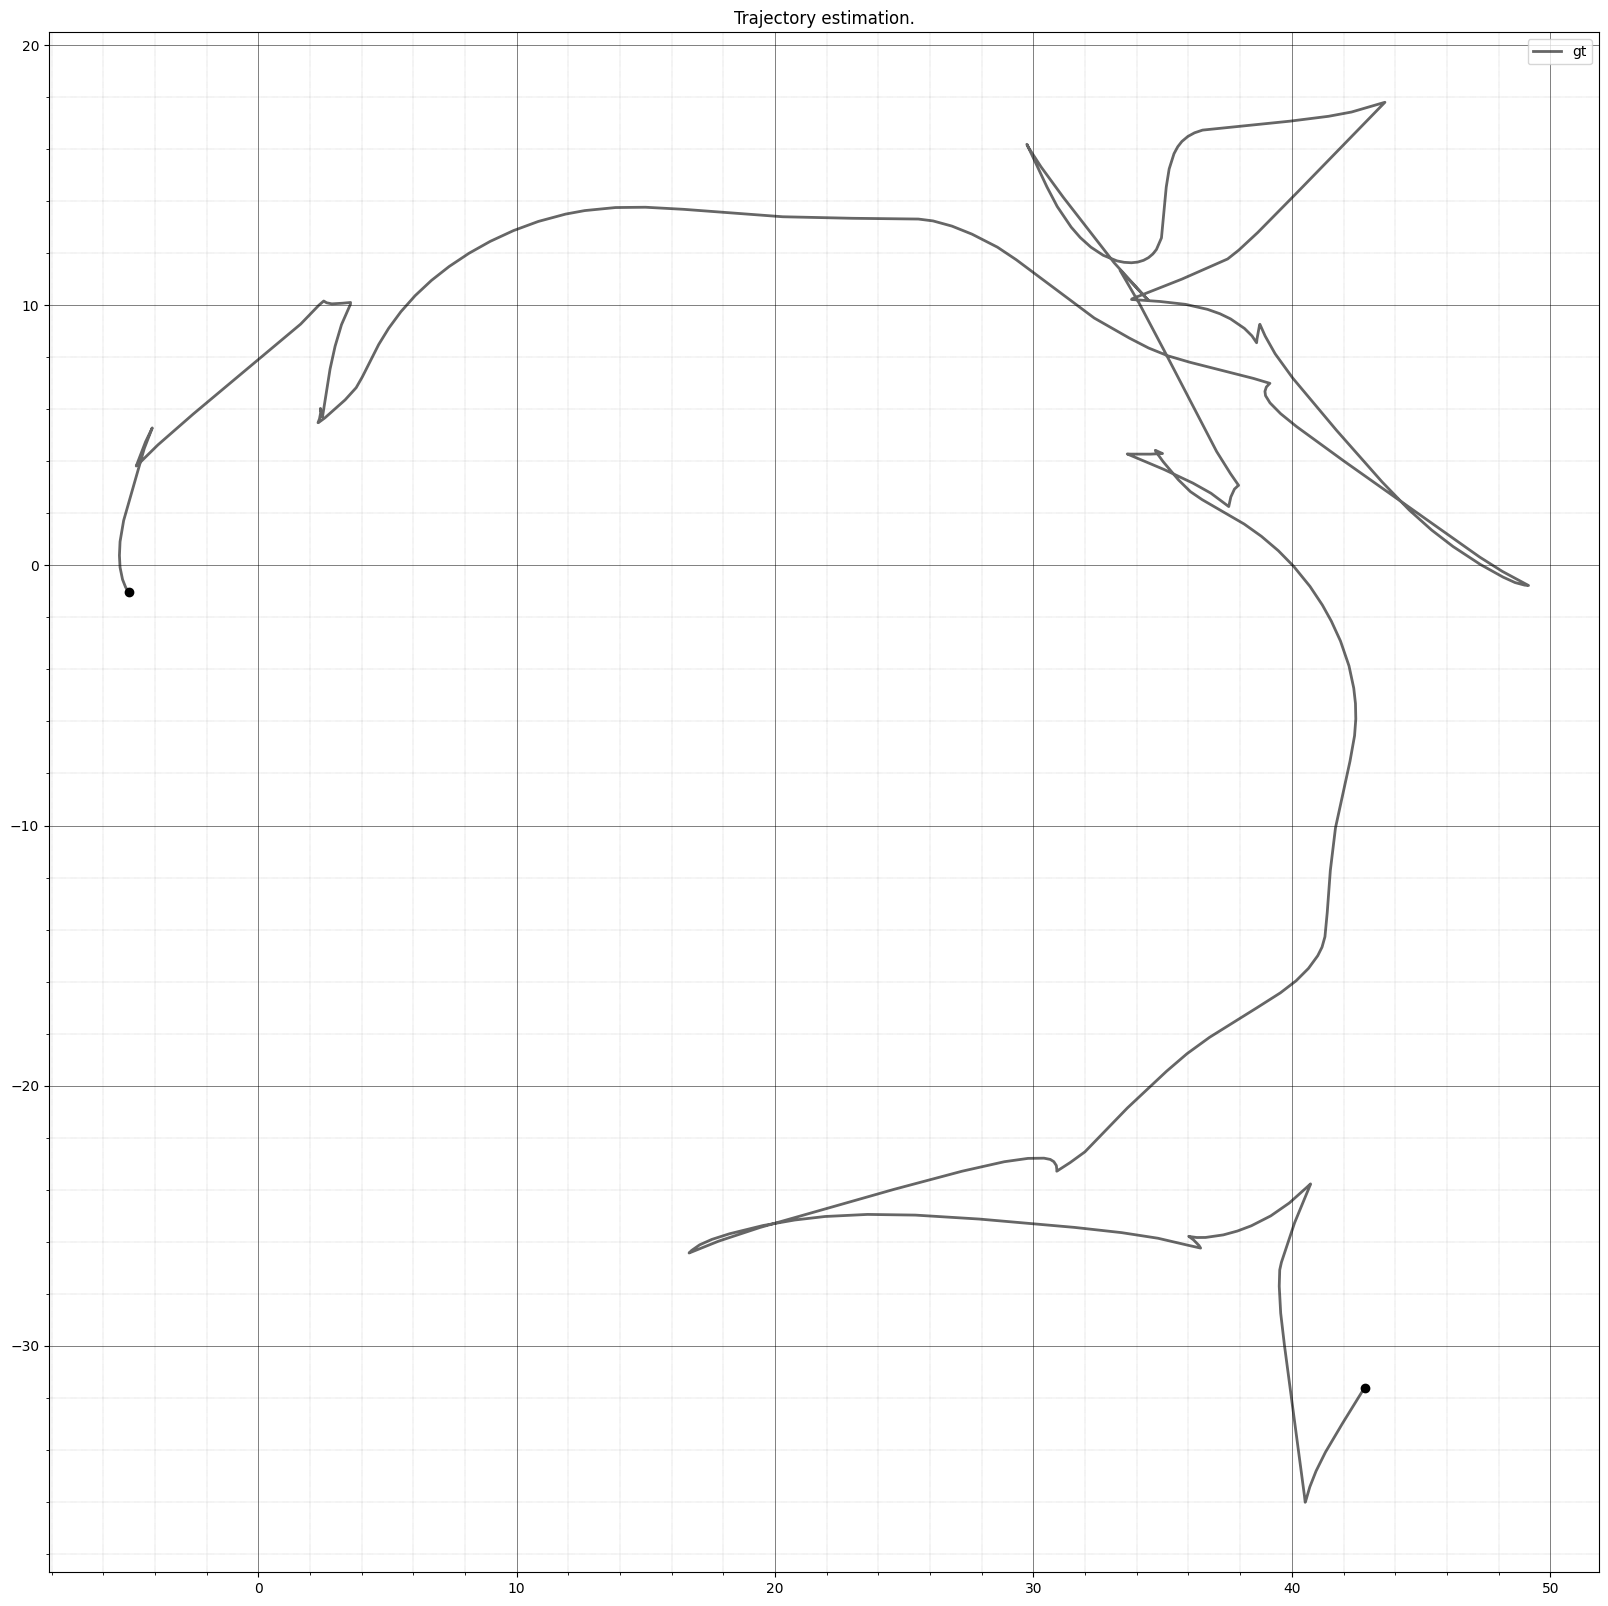

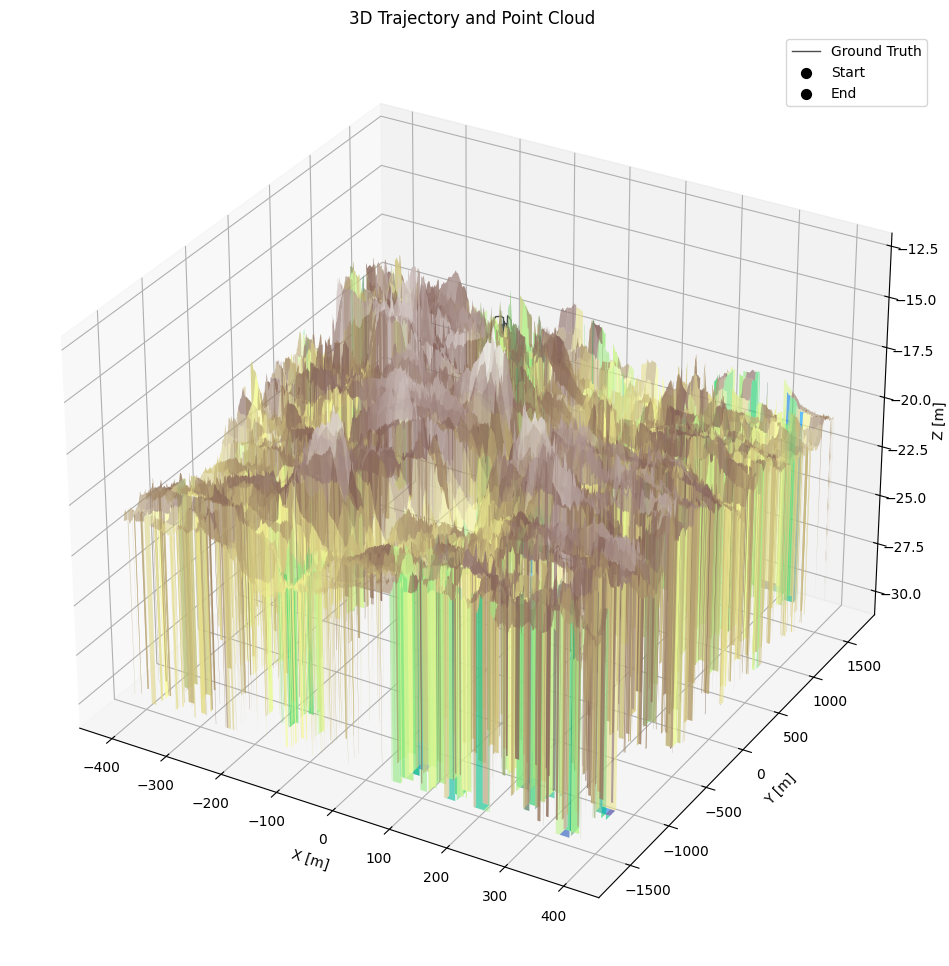

c:\Users\janis\Projekty\Magisterka\SonarOdometry\src\data_loader\evaluation_data_generator.py:286: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


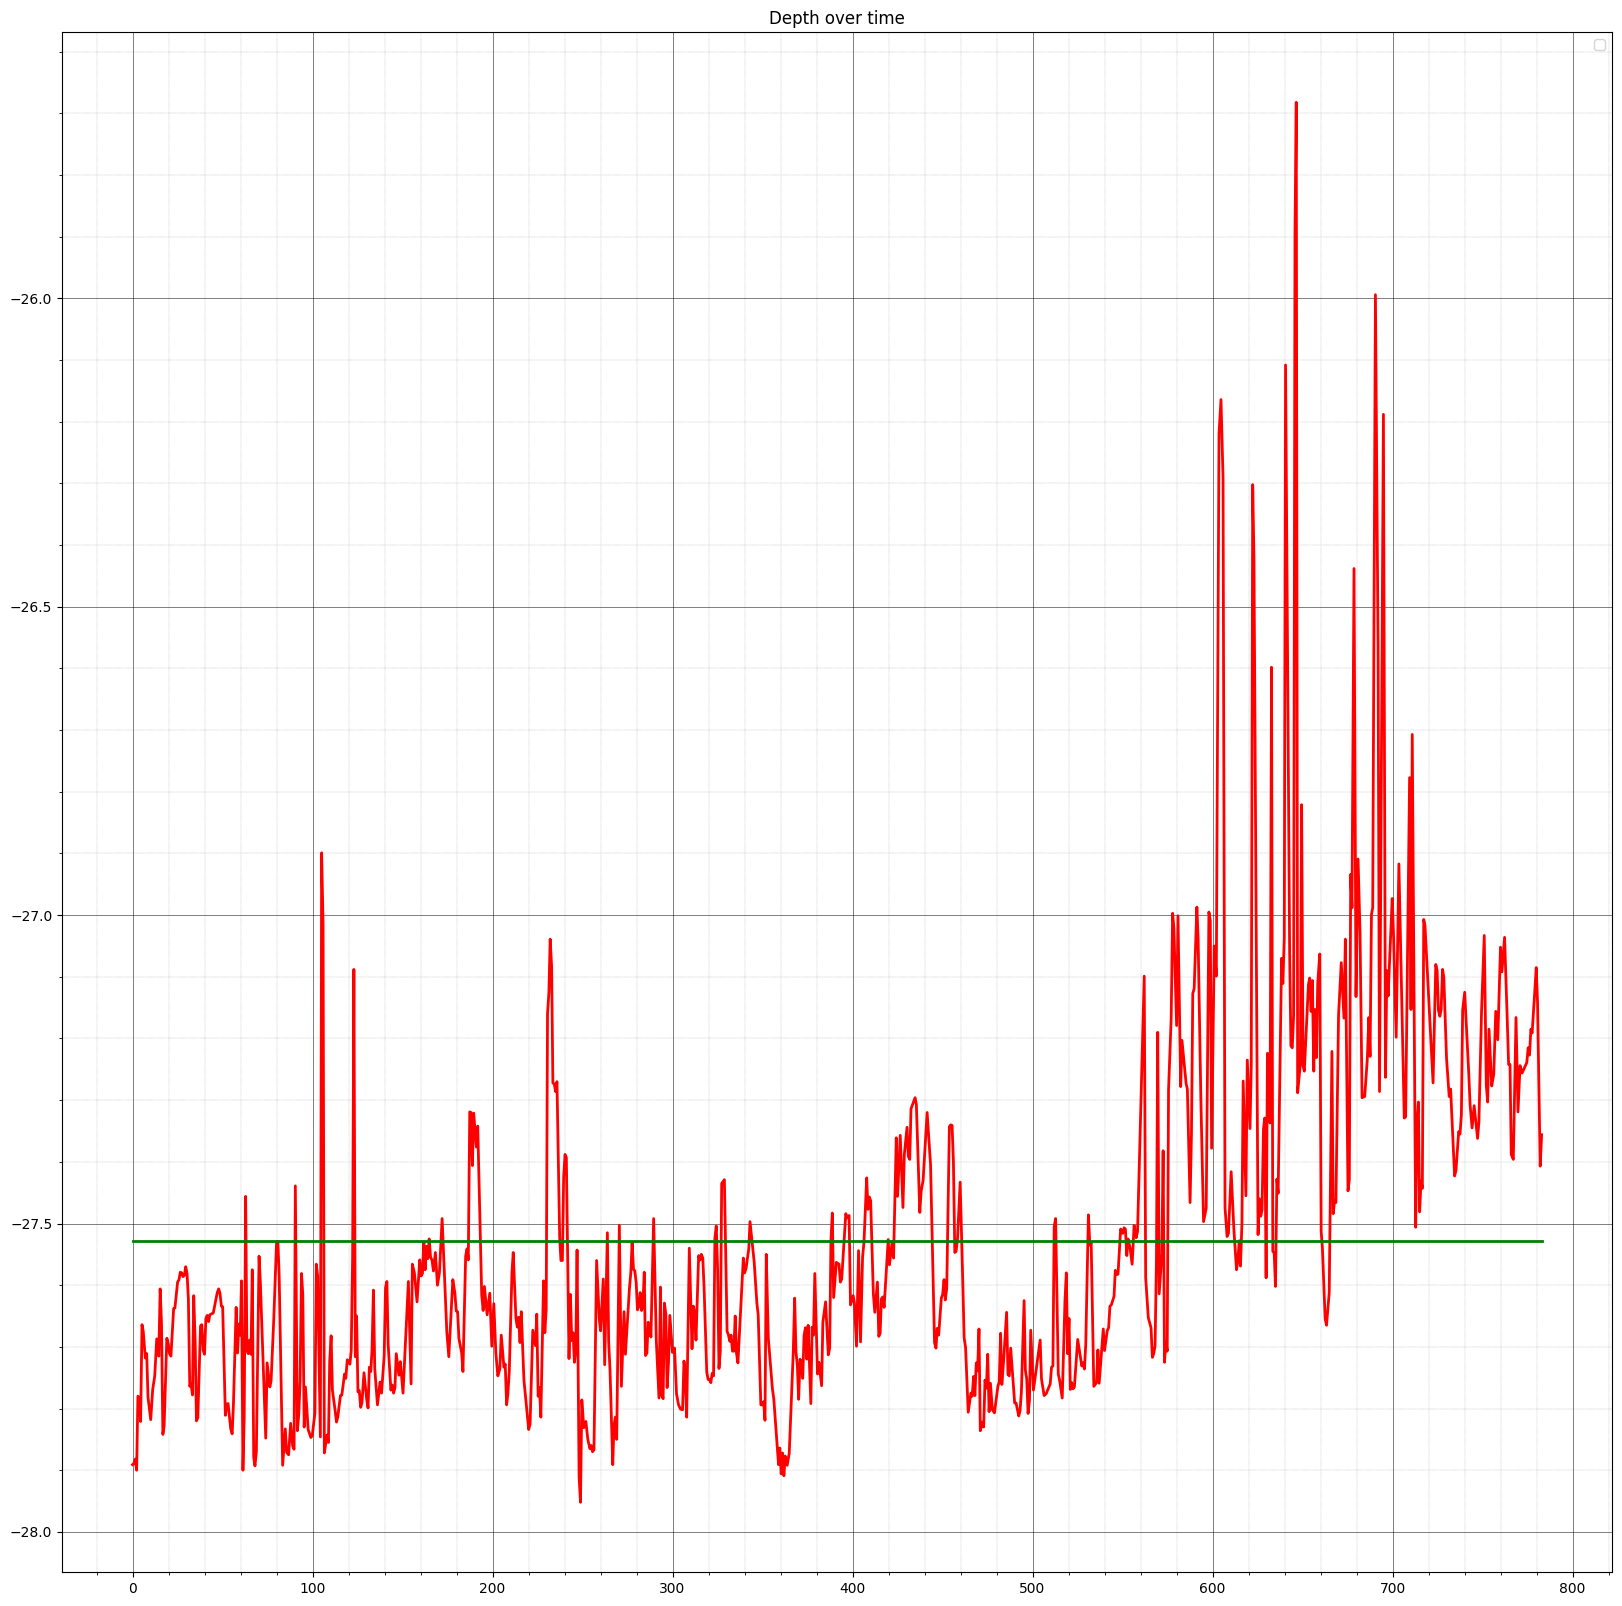

In [57]:

start = 0
end = 1

data_generator.generate_trajectory_map_2d(plane = 'xy', start = start, end = end, show = {'gt':True,'traj':False,'pts':False, 'align':False})

seabed_visu = {'heightmap_pth':'C:/Users/janis/Projekty/Magisterka/SonarOdometry/SonarOdometryDataset/bathymetry_maps/ocean2.png',
               'scalex':0.6, 
               'scaley':1.2,
               'max_height':15,
               'max_depth':30}
# seabed_visu = None
data_generator.generate_trajectory_map_3d(start = start, end = end, show = {'gt':True,'traj':False,'pts':False, 'align':False}, seabed_visu = seabed_visu)

data_generator.generate_timeseries(data_type = 'seabed_profile', title = 'Depth over time', start = start, end = end)

In [58]:
# --- sequence visualisation ---

start_frame = 0
end_frame = 300
wait_time_ms = 10 

show_key_points = True

window_name = 'FLS'
cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
cv2.resizeWindow(window_name, 800, 400)

with torch.no_grad():
    for frame_idx in range(start_frame, end_frame, 1):

        
        t, frame, pose, frame_np = data_generator.get_sample(frame_idx, return_visu=True)

        if show_key_points:
            coords, patches_f, patches_c, fmap = patchifier(frame, mode='harris')
            frame_np_visu, harris_response = patchifier.get_visu(frame, coords)
            frame_keypoints = img_polar2cart(frame_np_visu, r_min, r_max, theta_max, out_shape=None, bg=0)
        else:
            frame_keypoints = frame_np

        frame_keypoints = cv2.putText(frame_keypoints, f'frame: {frame_idx}', (40, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
        cv2.imshow(window_name, frame_keypoints)
        

        key = cv2.waitKey(wait_time_ms) & 0xFF
        if key == ord('q'):
            break

cv2.destroyAllWindows()